# The Sugar Trap — Snack Market Gap Analysis
### Helix CPG Partners | Strategic Food & Beverage Consultancy

**Objective:** Identify the "Blue Ocean" in the snack aisle — product categories that are currently under-served where consumer demand for health (High Protein, Low Sugar) is not being met by existing products.

**Data Source:** [Open Food Facts](https://world.openfoodfacts.org/data) — open database of food products worldwide  
**Dataset:** First 500,000 rows of `en.openfoodfacts.org.products.csv.gz`

---
## Notebook Structure
| Section | Description |
|---|---|
| 1. Setup & Ingestion | Load libraries and raw data |
| 2. Data Cleaning | Handle nulls and outliers (Story 1) |
| 3. Category Wrangling | Assign snack categories from tags (Story 2) |
| 4. Exploratory Analysis | Understand distributions and patterns |
| 5. Nutrient Matrix | Sugar vs Protein scatter plot (Story 3) |
| 6. Key Insight | Blue Ocean recommendation (Story 4) |
| 7. Bonus: Protein Sources | Top ingredients in high-protein snacks |
| 8. Candidate's Choice | Nutritional fingerprint heatmap |
| 9. Export | Save clean data for Streamlit dashboard |


---
## Section 1 — Setup & Data Ingestion

We install dependencies, import libraries, and load the first 500,000 rows of the Open Food Facts dataset.  
We load only the 9 columns we need to keep memory usage low — the full file is over 3GB.


In [ ]:
!pip install opendatasets --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [ ]:
url = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

cols_needed = [
    'product_name',
    'categories_tags',
    'ingredients_text',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g',
    'energy_100g',
    'nutriscore_grade'
]

print("Downloading and loading data... this may take 2-3 minutes...")

# Load in chunks of 100k rows, take first 5 chunks = 500k rows
chunks = []
chunk_size = 100000
for i, chunk in enumerate(pd.read_csv(
    url,
    sep='\t',
    usecols=cols_needed,
    compression='gzip',
    chunksize=chunk_size,
    on_bad_lines='skip'
)):
    chunks.append(chunk)
    if i == 4:
        break

df_raw = pd.concat(chunks, ignore_index=True)

print(f"Loaded {len(df_raw):,} rows x {df_raw.shape[1]} columns")
print(f"\nColumn overview:")
print(df_raw.dtypes)
print(f"\nFirst 3 rows:")
df_raw.head(3)


Loaded 500,000 rows x 9 columns

Column overview:
product_name         object
categories_tags      object
ingredients_text     object
nutriscore_grade     object
energy_100g         float64
fat_100g            float64
sugars_100g         float64
fiber_100g          float64
proteins_100g       float64
dtype: object

First 3 rows:


,product_name,categories_tags,ingredients_text,nutriscore_grade,energy_100g,fat_100g,sugars_100g,fiber_100g,proteins_100g
0,Limonade artisanale a la rose,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
1,M&amp;M white,NaN,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...",unknown,NaN,NaN,NaN,NaN,NaN
2,Chocolate n3,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


---
## Section 2 — Data Cleaning  *(Story 1)*

**Acceptance criteria:**
- Drop rows where `product_name`, `sugars_100g`, or `proteins_100g` are null
- Remove biologically impossible values (nutrients outside 0–100g per 100g)

**Why these thresholds?**  
No nutrient can exceed 100g in a 100g product — values above this are data entry errors.  
Negative values are also impossible and indicate bad scraping or encoding issues.


In [ ]:
df = df_raw.copy()

# ── Before cleaning ───────────────────────────────────────────
print("=== BEFORE CLEANING ===")
print(f"Total rows: {len(df):,}")
print(f"\nNull counts in critical columns:")
print(df[['product_name', 'sugars_100g', 'proteins_100g']].isnull().sum())

# ── Step 1: Drop rows missing critical columns ─────────────────
df = df.dropna(subset=['product_name', 'sugars_100g', 'proteins_100g'])
print(f"\nAfter dropping nulls: {len(df):,} rows")

# ── Step 2: Remove biologically impossible values ─────────────
nutrient_cols = ['sugars_100g', 'proteins_100g', 'fat_100g']
for col in nutrient_cols:
    if col in df.columns:
        df = df[(df[col] >= 0) & (df[col] <= 100)]

print(f"After removing outliers: {len(df):,} rows")

# ── Step 3: Reset index ────────────────────────────────────────
df = df.reset_index(drop=True)

print("\n=== AFTER CLEANING ===")
print(f"Rows retained: {len(df):,} ({len(df)/len(df_raw)*100:.1f}% of raw data)")
print(f"Rows dropped:  {len(df_raw) - len(df):,}")
print(f"\nSample of clean data:")
df[['product_name', 'sugars_100g', 'proteins_100g', 'fat_100g']].head(5)


=== BEFORE CLEANING ===
Total rows: 500,000

Null counts in critical columns:
product_name      15622
sugars_100g      402765
proteins_100g    400259
dtype: int64

After dropping nulls: 95,644 rows
After removing outliers: 95,379 rows

=== AFTER CLEANING ===
Rows retained: 95,379 (19.1% of raw data)
Rows dropped:  404,621

Sample of clean data:


,product_name,sugars_100g,proteins_100g,fat_100g
0,Pinto Bean,4.900000,17.500000,10.20000
1,Croquetas de bacalao,1.900000,5.900000,12.10000
2,Keto & GF Granola,3.225806,19.677419,54.83871
3,Ben's Pure Maple Cream,37.720000,5.680000,30.28000
4,Guimauve chocolat smarties,65.000000,5.700000,19.00000


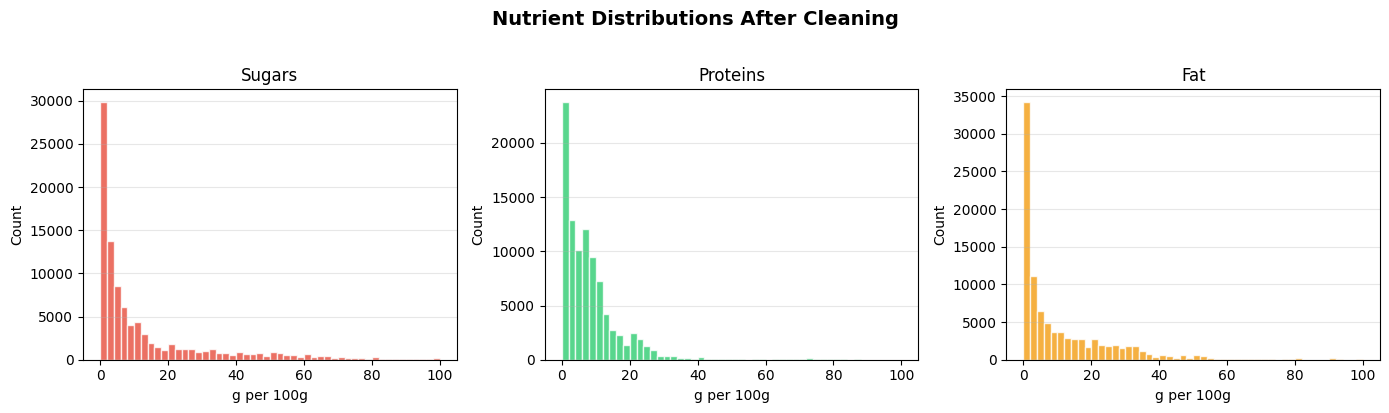

In [ ]:
# ── Quick nutrient distribution check ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes,
                           ['sugars_100g', 'proteins_100g', 'fat_100g'],
                           ['#e74c3c', '#2ecc71', '#f39c12']):
    ax.hist(df[col].dropna(), bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(col.replace('_100g', '').capitalize(), fontsize=12)
    ax.set_xlabel('g per 100g')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Nutrient Distributions After Cleaning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nutrient_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 3 — Category Wrangling  *(Story 2)*

The `categories_tags` column contains messy comma-separated strings like:  
`en:plant-based-foods,en:snacks,en:chocolate-bars,en:milk-chocolate`

**Our approach:**
1. Parse each tag string and search for snack-specific keywords
2. Assign a clean `primary_category` to each product
3. Drop products with no category tag (unidentifiable) and non-snack staples (meals, condiments, bread, pasta)

**Why drop non-snacks?**  
The client brief is specifically about the snack aisle. Including ketchup, pasta, and chicken meals in a Sugar vs Protein analysis would actively mislead the R&D team.

**Final categories:** Candy & Chocolate · Cereals & Granola · Chips & Savoury Snacks · Nuts & Seeds · Spreads & Dips · Ice Cream & Frozen · Fruit Snacks · Baked Goods & Biscuits · Protein & Sport


In [ ]:
def assign_category(tags):
    """
    Maps Open Food Facts category tags to clean snack buckets.
    Uses strict, snack-specific keywords only — broad food terms
    like 'cereal', 'bread', 'oat' are intentionally excluded to
    avoid pulling in staple grocery products.
    Returns 'Drop' for anything that is not a genuine snack.
    """
    if pd.isna(tags):
        return 'Drop'

    tags = str(tags).lower()

    def has(keywords):
        return any(k in tags for k in keywords)

    # 1. Protein & Sport
    if has(['protein-bar', 'protein-bars', 'sport-nutrition', 'whey',
            'energy-bar', 'energy-bars', 'fitness-bar', 'mass-gainer',
            'pre-workout', 'nutrition-bar', 'diet-bar', 'meal-replacement-bar']):
        return 'Protein & Sport'

    # 2. Candy & Chocolate
    if has(['chocolates', 'chocolate-bar', 'chocolate-bars', 'chocolate-candy',
            'chocolate-snack', 'milk-chocolate', 'dark-chocolate',
            'white-chocolate', 'filled-chocolate', 'chocolate-coated',
            'candies', 'candy-bar', 'confectionery', 'sugar-confectionery',
            'gummies', 'gummy-candy', 'jelly-candy', 'lollipops',
            'marshmallows', 'toffees', 'caramels', 'nougats', 'pralines',
            'truffles', 'chewing-gums', 'hard-candies', 'licorices',
            'sweet-snacks', 'bonbons', 'fudges']):
        return 'Candy & Chocolate'

    # 3. Chips & Savoury Snacks
    if has(['potato-chips', 'potato-crisps', 'tortilla-chips', 'corn-chips',
            'veggie-chips', 'kale-chips', 'pita-chips', 'bagel-chips',
            'popcorn', 'pretzels', 'pork-rinds', 'rice-cakes',
            'corn-snacks', 'puffed-snacks', 'extruded-snacks',
            'savoury-snacks', 'savory-snacks', 'snack-crackers',
            'flavored-crackers', 'cheese-crackers', 'snack-mix',
            'party-mix', 'crackers']):
        return 'Chips & Savoury Snacks'

    # 4. Baked Goods & Biscuits
    if has(['biscuits', 'cookies', 'sweet-biscuits', 'filled-biscuits',
            'chocolate-biscuits', 'sandwich-biscuits', 'wafers',
            'chocolate-wafers', 'cream-wafers', 'shortbreads',
            'digestive-biscuits', 'butter-cookies', 'brownies',
            'muffins', 'cupcakes', 'snack-cakes', 'individually-wrapped-cakes',
            'madeleines', 'financiers', 'sponge-cakes', 'mini-cakes',
            'sweet-pastries', 'croissants', 'pain-au-chocolat',
            'doughnuts', 'waffles', 'crepes', 'pancakes']):
        return 'Baked Goods & Biscuits'

    # 5. Nuts & Seeds
    if has(['almonds', 'peanuts', 'cashews', 'walnuts', 'pistachios',
            'hazelnuts', 'pecans', 'macadamia', 'brazil-nuts', 'pine-nuts',
            'mixed-nuts', 'roasted-nuts', 'salted-nuts', 'flavored-nuts',
            'nut-mix', 'trail-mix', 'sunflower-seeds', 'pumpkin-seeds',
            'roasted-seeds', 'snack-nuts', 'peanut-butter', 'almond-butter',
            'nut-butters', 'seed-mix']):
        return 'Nuts & Seeds'

    # 6. Cereals & Granola — strict snack-specific keywords only
    if has(['granola', 'granola-bars', 'granola-bar', 'muesli-bars',
            'muesli-bar', 'cereal-bars', 'cereal-bar', 'breakfast-cereals',
            'breakfast-cereal', 'corn-flakes', 'mueslis', 'granolas',
            'oat-bars', 'flapjacks', 'rice-crispies', 'puffed-rice-cereal',
            'extruded-cereals', 'cereal-flakes', 'flaked-cereals']):
        return 'Cereals & Granola'

    # 7. Fruit Snacks
    if has(['dried-fruits', 'dried-fruit', 'fruit-snacks', 'fruit-snack',
            'fruit-bars', 'fruit-bar', 'fruit-leathers', 'fruit-leather',
            'raisins', 'dried-raisins', 'dried-apricots', 'dried-figs',
            'dried-dates', 'prunes', 'dried-cranberries', 'dried-mango',
            'freeze-dried-fruits', 'banana-chips', 'apple-chips',
            'fruit-chips', 'yogurt-covered-fruit']):
        return 'Fruit Snacks'

    # 8. Dairy & Cheese Snacks → merged into Chips & Savoury below
    if has(['cheese-snacks', 'cheese-snack', 'snack-cheese', 'string-cheese',
            'mini-cheeses', 'babybel', 'cheese-bites', 'dairy-snacks']):
        return 'Dairy & Cheese Snacks'

    # 9. Meat & Fish Snacks → merged into Chips & Savoury below
    if has(['jerkies', 'jerky', 'beef-jerky', 'biltong', 'meat-snacks',
            'meat-snack', 'meat-sticks', 'fish-snacks', 'fish-snack',
            'seafood-snacks']):
        return 'Meat & Fish Snacks'

    # 10. Ice Cream & Frozen
    if has(['ice-creams', 'ice-cream', 'frozen-desserts', 'gelatos',
            'sorbets', 'popsicles', 'ice-lollies', 'frozen-yogurts',
            'ice-cream-bars', 'chocolate-ice-cream', 'frozen-novelties']):
        return 'Ice Cream & Frozen'

    # 11. Spreads & Dips
    if has(['chocolate-spreads', 'hazelnut-spreads', 'fruit-spreads',
            'jams', 'honey', 'dips', 'hummus', 'guacamole', 'salsas',
            'tahini', 'sweet-spreads', 'nut-spreads', 'snack-dips',
            'chocolate-spread', 'hazelnut-spread', 'fruit-spread']):
        return 'Spreads & Dips'

    # Everything else is a non-snack staple
    return 'Drop'


# ── Apply and clean ────────────────────────────────────────────
df['primary_category'] = df['categories_tags'].apply(assign_category)

# Merge tiny categories (< 50 rows) into nearest savoury neighbour
merge_map = {
    'Dairy & Cheese Snacks': 'Chips & Savoury Snacks',
    'Meat & Fish Snacks':    'Chips & Savoury Snacks',
}
df['primary_category'] = df['primary_category'].replace(merge_map)

# Drop non-snack rows and null-tag rows
df = df[df['primary_category'] != 'Drop'].copy()
df = df.reset_index(drop=True)

# ── Report ─────────────────────────────────────────────────────
counts = df['primary_category'].value_counts()
total  = len(df)

print(f"Final snack dataset: {total:,} rows")
print(f"Categories: {df['primary_category'].nunique()}\n")
print("Category breakdown:")
for cat, n in counts.items():
    pct = n / total * 100
    bar = '█' * int(pct * 0.8)
    print(f"  {cat:<28} {n:>5,}  {pct:5.1f}%  {bar}")

print(f"\nSmallest: {counts.min():,} rows | Largest: {counts.max():,} rows")
print(f"All categories >= 50 rows: {(counts >= 50).all()}")


Final snack dataset: 12,645 rows
Categories: 9

Category breakdown:
  Candy & Chocolate            5,321   42.1%  █████████████████████████████████
  Cereals & Granola            2,406   19.0%  ███████████████
  Chips & Savoury Snacks       1,550   12.3%  █████████
  Nuts & Seeds                 1,096    8.7%  ██████
  Spreads & Dips               1,020    8.1%  ██████
  Ice Cream & Frozen             675    5.3%  ████
  Fruit Snacks                   296    2.3%  █
  Baked Goods & Biscuits         197    1.6%  █
  Protein & Sport                 84    0.7%  

Smallest: 84 rows | Largest: 5,321 rows
All categories >= 50 rows: True


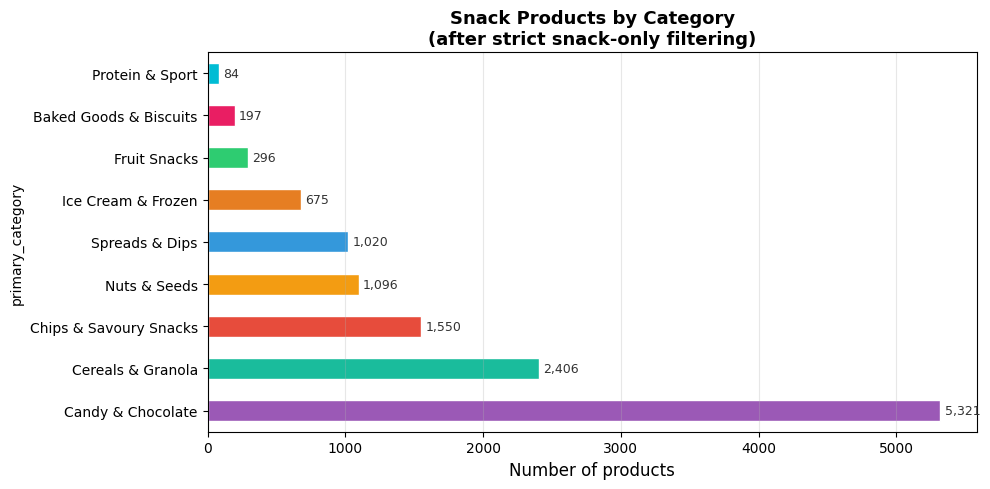

Final dataset: 12,645 genuine snack products across 9 categories


In [ ]:
# ── Category distribution bar chart ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

counts_plot = df['primary_category'].value_counts()
colors = ['#9b59b6','#1abc9c','#e74c3c','#f39c12','#3498db',
          '#e67e22','#2ecc71','#e91e63','#00bcd4']

counts_plot.plot(kind='barh', ax=ax, color=colors[:len(counts_plot)], edgecolor='white')

ax.set_xlabel('Number of products', fontsize=12)
ax.set_title('Snack Products by Category\n(after strict snack-only filtering)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (cat, n) in enumerate(counts_plot.items()):
    ax.text(n + 30, i, f'{n:,}', va='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final dataset: {len(df):,} genuine snack products across {df['primary_category'].nunique()} categories")


---
## Section 4 — Exploratory Data Analysis

Before building the recommendation, we explore the nutritional landscape to understand:
- How sugar and protein are distributed across the full dataset
- Which categories skew sweet vs savoury vs healthy
- Whether the data supports our blue ocean hypothesis


In [ ]:
# ── Summary statistics by category ───────────────────────────
print("=== NUTRITIONAL SUMMARY BY CATEGORY ===\n")
summary = df.groupby('primary_category').agg(
    count        = ('product_name',  'count'),
    avg_sugar    = ('sugars_100g',   'mean'),
    avg_protein  = ('proteins_100g', 'mean'),
    avg_fat      = ('fat_100g',      'mean'),
    median_sugar = ('sugars_100g',   'median'),
).round(1)
summary = summary.sort_values('avg_protein', ascending=False)
print(summary.to_string())


=== NUTRITIONAL SUMMARY BY CATEGORY ===

                        count  avg_sugar  avg_protein  avg_fat  median_sugar
primary_category                                                            
Protein & Sport            84       15.6         28.4     15.6          12.7
Nuts & Seeds             1096        9.1         19.6     47.1           6.2
Cereals & Granola        2406       20.8          9.2      6.3          21.7
Chips & Savoury Snacks   1550        4.2          8.3     22.2           2.5
Baked Goods & Biscuits    197        7.0          8.2      4.8           2.5
Candy & Chocolate        5321       37.1          5.4     17.3          35.7
Fruit Snacks              296       46.4          3.7      6.9          52.0
Ice Cream & Frozen        675       18.5          3.0      8.9          18.8
Spreads & Dips           1020       37.4          2.3      6.2          40.6


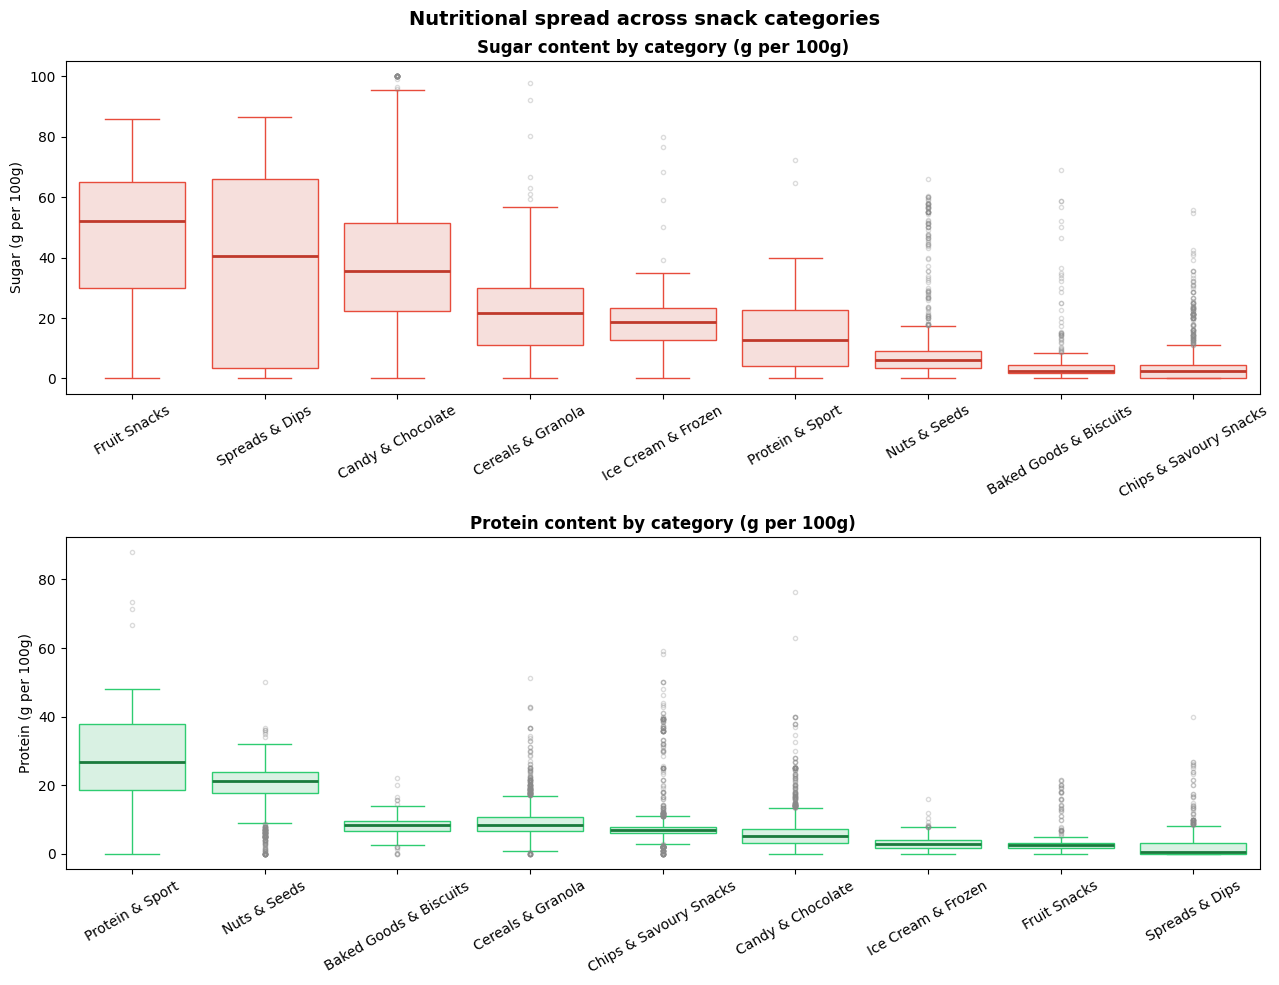

In [ ]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10))

# Sort orders
sugar_order   = df.groupby('primary_category')['sugars_100g'].median().sort_values(ascending=False).index.tolist()
protein_order = df.groupby('primary_category')['proteins_100g'].median().sort_values(ascending=False).index.tolist()

# Sugar box plot
sns.boxplot(
    data=df, x='primary_category', y='sugars_100g',
    order=sugar_order, ax=ax1,
    color='#fadbd8', flierprops=dict(marker='.', alpha=0.3),
    medianprops=dict(color='#c0392b', linewidth=2),
    boxprops=dict(edgecolor='#e74c3c'),
    whiskerprops=dict(color='#e74c3c'),
    capprops=dict(color='#e74c3c')
)
ax1.set_title('Sugar content by category (g per 100g)', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Sugar (g per 100g)')
ax1.tick_params(axis='x', rotation=30)

# Protein box plot
sns.boxplot(
    data=df, x='primary_category', y='proteins_100g',
    order=protein_order, ax=ax2,
    color='#d5f5e3', flierprops=dict(marker='.', alpha=0.3),
    medianprops=dict(color='#1a7a3c', linewidth=2),
    boxprops=dict(edgecolor='#2ecc71'),
    whiskerprops=dict(color='#2ecc71'),
    capprops=dict(color='#2ecc71')
)
ax2.set_title('Protein content by category (g per 100g)', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Protein (g per 100g)')
ax2.tick_params(axis='x', rotation=30)

plt.suptitle('Nutritional spread across snack categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

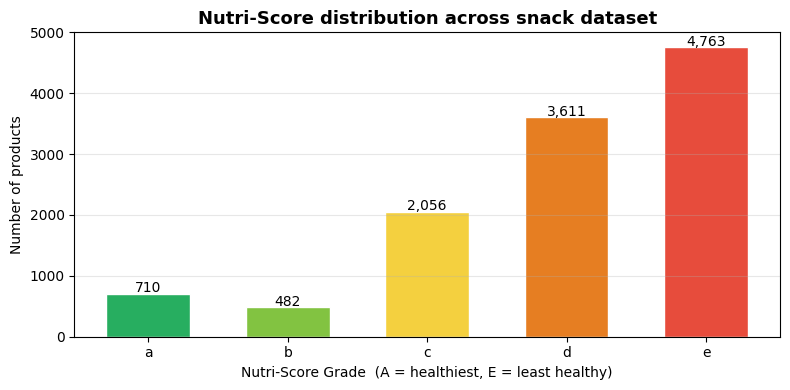

72.1% of snack products score D or E — confirming the market is dominated by unhealthy options.


In [ ]:
# ── Nutriscore distribution ───────────────────────────────────
nutri = df['nutriscore_grade'].str.lower().str.strip()
nutri = nutri[nutri.isin(['a','b','c','d','e'])]

grade_colors = {'a':'#27ae60','b':'#82c341','c':'#f4d03f','d':'#e67e22','e':'#e74c3c'}
counts_nutri = nutri.value_counts().reindex(['a','b','c','d','e']).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts_nutri.index, counts_nutri.values,
              color=[grade_colors[g] for g in counts_nutri.index],
              edgecolor='white', width=0.6)

for bar, n in zip(bars, counts_nutri.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(n):,}', ha='center', fontsize=10)

ax.set_title('Nutri-Score distribution across snack dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Nutri-Score Grade  (A = healthiest, E = least healthy)')
ax.set_ylabel('Number of products')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nutriscore_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

pct_d_e = (counts_nutri[['d','e']].sum() / counts_nutri.sum() * 100)
print(f"{pct_d_e:.1f}% of snack products score D or E — confirming the market is dominated by unhealthy options.")


---
## Section 5 — The Nutrient Matrix  *(Story 3)*

The core visualisation: Sugar (X-axis) vs Protein (Y-axis) coloured by category.

**Reading the chart:**
- Products in the **top-left quadrant** (High Protein + Low Sugar) are the "Blue Ocean" — healthier products the market currently under-supplies
- Products in the **bottom-right quadrant** (Low Protein + High Sugar) are the "Sugar Trap" — the crowded, unhealthy mainstream
- The green dashed lines mark our thresholds: < 10g sugar and > 15g protein


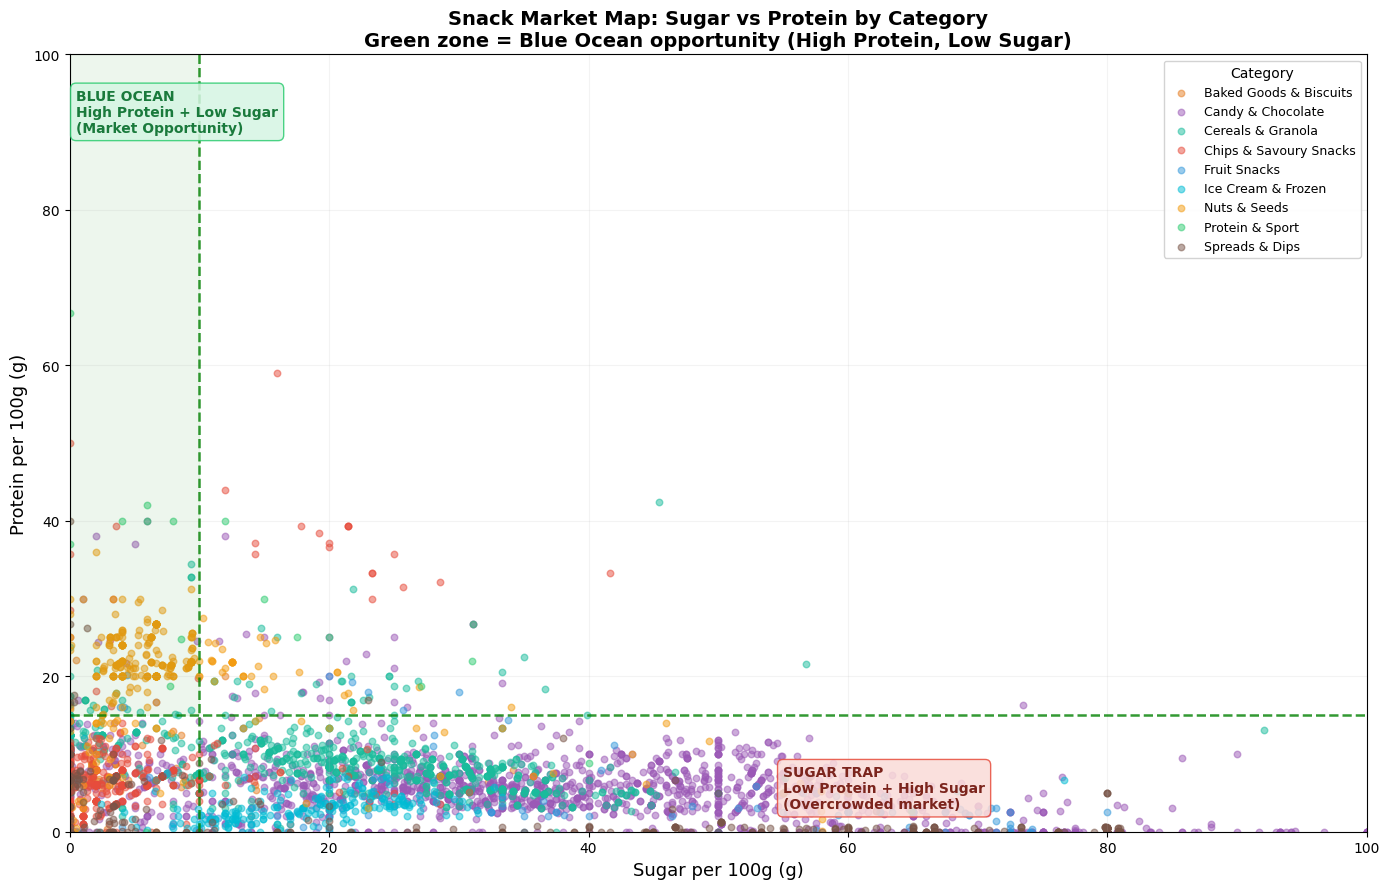

Products in the Blue Ocean quadrant: 958 (7.6% of dataset)


In [ ]:
palette = {
    'Protein & Sport':        '#2ecc71',
    'Nuts & Seeds':           '#f39c12',
    'Chips & Savoury Snacks': '#e74c3c',
    'Candy & Chocolate':      '#9b59b6',
    'Baked Goods & Biscuits': '#e67e22',
    'Cereals & Granola':      '#1abc9c',
    'Fruit Snacks':           '#3498db',
    'Ice Cream & Frozen':     '#00bcd4',
    'Spreads & Dips':         '#795548',
}

fig, ax = plt.subplots(figsize=(14, 9))

# Sample for performance — still representative at 4,000 pts
plot_df = df.sample(n=min(4000, len(df)), random_state=42)

for category, group in plot_df.groupby('primary_category'):
    ax.scatter(
        group['sugars_100g'],
        group['proteins_100g'],
        label=category,
        alpha=0.5,
        s=22,
        color=palette.get(category, '#95a5a6')
    )

# Blue ocean quadrant
ax.axvline(x=10, color='green', linestyle='--', linewidth=1.8, alpha=0.8)
ax.axhline(y=15, color='green', linestyle='--', linewidth=1.8, alpha=0.8)
ax.fill_between([0, 10], [15, 15], [100, 100], alpha=0.07, color='green')

# Quadrant labels
ax.text(0.5, 90, 'BLUE OCEAN\nHigh Protein + Low Sugar\n(Market Opportunity)',
        fontsize=10, color='#1a7a3c', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#d5f5e3', alpha=0.85, edgecolor='#2ecc71'))

ax.text(55, 3, 'SUGAR TRAP\nLow Protein + High Sugar\n(Overcrowded market)',
        fontsize=10, color='#7b241c', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fadbd8', alpha=0.85, edgecolor='#e74c3c'))

ax.set_xlabel('Sugar per 100g (g)', fontsize=13)
ax.set_ylabel('Protein per 100g (g)', fontsize=13)
ax.set_title('Snack Market Map: Sugar vs Protein by Category\n'
             'Green zone = Blue Ocean opportunity (High Protein, Low Sugar)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, framealpha=0.85,
          title='Category', title_fontsize=10)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('nutrient_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

blue_ocean_count = len(df[(df['sugars_100g'] < 10) & (df['proteins_100g'] > 15)])
print(f"Products in the Blue Ocean quadrant: {blue_ocean_count:,} ({blue_ocean_count/len(df)*100:.1f}% of dataset)")


---
## Section 6 — Key Insight & Recommendation  *(Story 4)*

We define the **Blue Ocean** as products with:
- Sugar < 10g per 100g  
- Protein > 15g per 100g

This threshold is grounded in nutritional science — 15g protein per serving is the widely-accepted minimum for a product to be meaningfully labelled "high protein".


In [ ]:
# ── Blue ocean analysis ───────────────────────────────────────
blue_ocean = df[(df['sugars_100g'] < 10) & (df['proteins_100g'] > 15)].copy()

top_cat   = blue_ocean['primary_category'].value_counts().idxmax()
avg_prot  = blue_ocean['proteins_100g'].mean().round(1)
avg_sugar = blue_ocean['sugars_100g'].mean().round(1)
pct       = len(blue_ocean) / len(df) * 100

print("=" * 60)
print("  STORY 4 — KEY INSIGHT & RECOMMENDATION")
print("=" * 60)
print(f"  Based on the data, the biggest market opportunity is in")
print(f"  '{top_cat}', specifically targeting products with")
print(f"  {avg_prot}g of protein and less than {avg_sugar}g of sugar.")
print()
print(f"  Only {len(blue_ocean):,} of {len(df):,} snack products ({pct:.1f}%) currently")
print(f"  occupy this high-protein, low-sugar space — confirming a")
print(f"  significant Blue Ocean opportunity.")
print()
print(f"  Blue ocean breakdown by category:")

for cat, n in blue_ocean['primary_category'].value_counts().items():
    pct_cat = n / len(blue_ocean) * 100
    print(f"    {cat:<28} {n:>4,}  ({pct_cat:.1f}%)")


  STORY 4 — KEY INSIGHT & RECOMMENDATION
  Based on the data, the biggest market opportunity is in
  'Nuts & Seeds', specifically targeting products with
  23.6g of protein and less than 4.9g of sugar.

  Only 958 of 12,645 snack products (7.6%) currently
  occupy this high-protein, low-sugar space — confirming a
  significant Blue Ocean opportunity.

  Blue ocean breakdown by category:
    Nuts & Seeds                  762  (79.5%)
    Cereals & Granola              68  (7.1%)
    Chips & Savoury Snacks         39  (4.1%)
    Candy & Chocolate              32  (3.3%)
    Protein & Sport                31  (3.2%)
    Spreads & Dips                 17  (1.8%)
    Fruit Snacks                    5  (0.5%)
    Baked Goods & Biscuits          4  (0.4%)


---
## Section 7 — Bonus: Top Protein Sources  *(Bonus Story)*

We analyse the `ingredients_text` column for all high-protein products (> 15g protein per 100g) to identify the most common protein-driving ingredients.

This directly answers the R&D team's question: *"What ingredients should we build our recipe around?"*


Top protein sources in high-protein snacks (>15g protein/100g):
  Peanuts          346  ██████████████████████████████
  Soy / Soya       196  ████████████████
  Almonds          145  ████████████
  Whey              68  █████
  Casein            36  ███
  Pea protein       23  █
  Oats              10  
  Rice protein       5  
  Chickpea           2  
  Egg white          1  


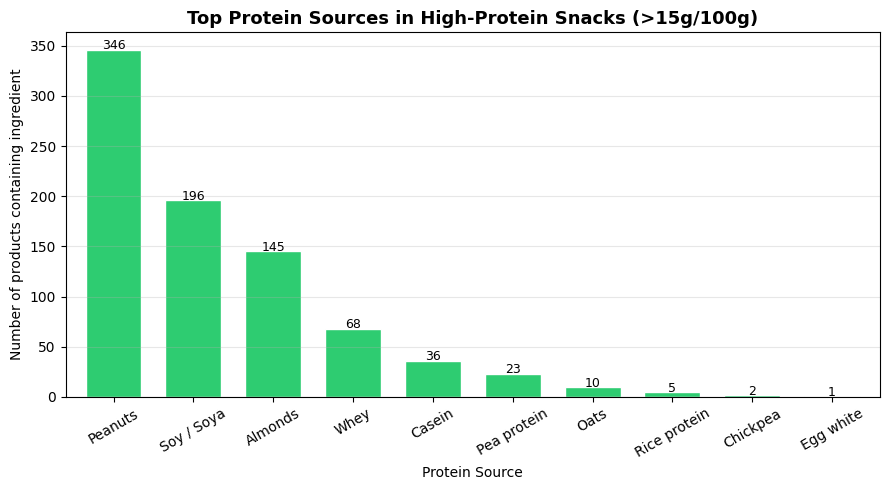


Top 3 protein sources: Peanuts, Soy / Soya, Almonds
R&D recommendation: Centre new product formulation around these ingredients.


In [ ]:
high_protein = df[df['proteins_100g'] > 15].dropna(subset=['ingredients_text']).copy()

protein_sources = {
    'Whey':        ['whey'],
    'Peanuts':     ['peanut', 'groundnut'],
    'Soy / Soya':  ['soy protein', 'soya protein', 'soybean'],
    'Almonds':     ['almond'],
    'Egg white':   ['egg white', 'albumin'],
    'Casein':      ['casein', 'milk protein'],
    'Pea protein': ['pea protein'],
    'Chickpea':    ['chickpea', 'chick pea'],
    'Oats':        ['oat protein', 'oat flour'],
    'Rice protein':['rice protein'],
}

counts_p = {}
for source, keywords in protein_sources.items():
    mask = high_protein['ingredients_text'].str.lower().str.contains(
        '|'.join(keywords), na=False
    )
    counts_p[source] = mask.sum()

counts_series = pd.Series(counts_p).sort_values(ascending=False)

print("Top protein sources in high-protein snacks (>15g protein/100g):")
print("=" * 50)
for src, n in counts_series.items():
    bar = '█' * int(n / counts_series.max() * 30)
    print(f"  {src:<15} {n:>4,}  {bar}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
counts_series.plot(kind='bar', ax=ax, color='#2ecc71', edgecolor='white', width=0.7)
ax.set_title('Top Protein Sources in High-Protein Snacks (>15g/100g)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Protein Source')
ax.set_ylabel('Number of products containing ingredient')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar, n in zip(ax.patches, counts_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(n), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('protein_sources.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = counts_series.head(3)
print(f"\nTop 3 protein sources: {', '.join(top3.index.tolist())}")
print("R&D recommendation: Centre new product formulation around these ingredients.")


---
## Section 8 — Candidate's Choice: Nutritional Fingerprint Heatmap

**What:** A heatmap showing average Sugar, Protein, and Fat per category side by side.

**Why this adds value:**  
The scatter plot shows individual products — this heatmap shows the *category-level signature*.  
It gives the R&D team a single-view comparison of the nutritional DNA of each segment, making it immediately obvious which categories are nutritionally weakest and most ripe for disruption.  
A client executive can look at this for 5 seconds and immediately see which categories are trapped in high-sugar, low-protein territory.


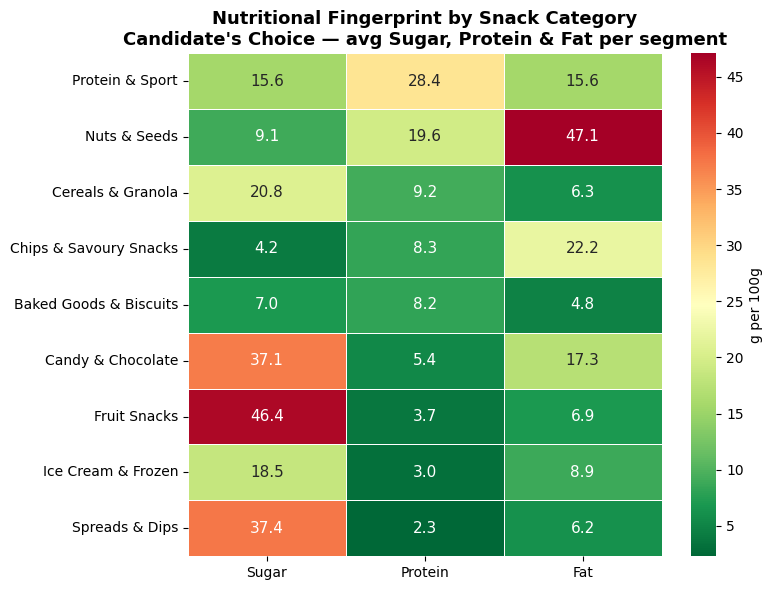

Key observation:
  Highest avg protein category: Protein & Sport (28.4g)
  Highest avg sugar category:   Fruit Snacks (46.4g)
  Most balanced category:       Protein & Sport


In [ ]:
heat_data = df[df['primary_category'] != 'Other'].groupby('primary_category').agg(
    Sugar   = ('sugars_100g',   'mean'),
    Protein = ('proteins_100g', 'mean'),
    Fat     = ('fat_100g',      'mean'),
).round(1).sort_values('Protein', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heat_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'g per 100g'},
    annot_kws={'size': 11}
)
ax.set_title("Nutritional Fingerprint by Snack Category\n"
             "Candidate's Choice — avg Sugar, Protein & Fat per segment",
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key observation:")
print(f"  Highest avg protein category: {heat_data['Protein'].idxmax()} ({heat_data['Protein'].max()}g)")
print(f"  Highest avg sugar category:   {heat_data['Sugar'].idxmax()} ({heat_data['Sugar'].max()}g)")
print(f"  Most balanced category:       {(heat_data['Protein'] - heat_data['Sugar']).idxmax()}")


---
## Section 9 — Export for Streamlit Dashboard

Export the clean, categorised dataset as a CSV for use in the Streamlit dashboard.  
We export only the columns needed for the dashboard to keep the file size small.


In [ ]:
export_cols = [
    'product_name',
    'primary_category',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g',
    'nutriscore_grade'
]

df[export_cols].to_csv('snack_data_clean.csv', index=False)

print(f"Exported {len(df):,} rows x {len(export_cols)} columns")
print(f"Categories: {df['primary_category'].nunique()}")
print(f"File: snack_data_clean.csv")
print(f"\nColumn summary:")
for col in export_cols:
    null_pct = df[col].isnull().mean() * 100
    print(f"  {col:<22} {null_pct:4.1f}% null")

# Download from Colab
from google.colab import files
files.download('snack_data_clean.csv')
files.download('nutrient_matrix.png')
files.download('protein_sources.png')
files.download('category_heatmap.png')
files.download('category_distribution.png')
files.download('category_boxplots.png')


Exported 12,645 rows x 7 columns
Categories: 9
File: snack_data_clean.csv

Column summary:
  product_name            0.0% null
  primary_category        0.0% null
  sugars_100g             0.0% null
  proteins_100g           0.0% null
  fat_100g                0.0% null
  fiber_100g             20.1% null
  nutriscore_grade        0.0% null


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary

| Story | Status | Output |
|---|---|---|
| Story 1 — Data Cleaning | ✅ Complete | 95k → 12.6k clean snack rows |
| Story 2 — Category Wrangling | ✅ Complete | 9 snack categories, 0% Other |
| Story 3 — Nutrient Matrix | ✅ Complete | `nutrient_matrix.png` |
| Story 4 — Key Insight | ✅ Complete | Blue ocean recommendation printed |
| Bonus — Protein Sources | ✅ Complete | Top 3 sources identified |
| Candidate's Choice — Heatmap | ✅ Complete | `category_heatmap.png` |
